In [1]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
print(housing)

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]], shape=(20640, 8)), 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)), 'frame': None, 'target_names': ['MedHouseVal'], 'feature_names': ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'], 'DESCR': '.. _california_housing_dataset

In [2]:
import pandas as pd

#load it as pandas dataframe
df = pd.DataFrame(data=housing.data, columns=housing.feature_names)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [3]:
# Add the target column
df['price'] = housing.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# Check shape
df.shape

(20640, 9)

In [5]:
# Check stats data
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [6]:
# somewhere the data is in thousands and elsewhere in points
# we HAVE to standardize it

In [7]:
# Pre processing
# check for null values
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
price         0
dtype: int64

In [8]:
# Check corelation

# Why Bother Checking?
# Find what matters: Maybe "Number of bathrooms" matters more than "Year built"
# Remove useless stuff: Don't waste time on features that don't affect price
# Spot weirdness: If "Rooms" and "Price" are negatively correlated (rooms up, price down) - something's wrong with your data!

# Bottom line: You're asking "Which features actually predict house prices?" Correlation helps answer that.
correlation_data = df.corr()
correlation_data

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


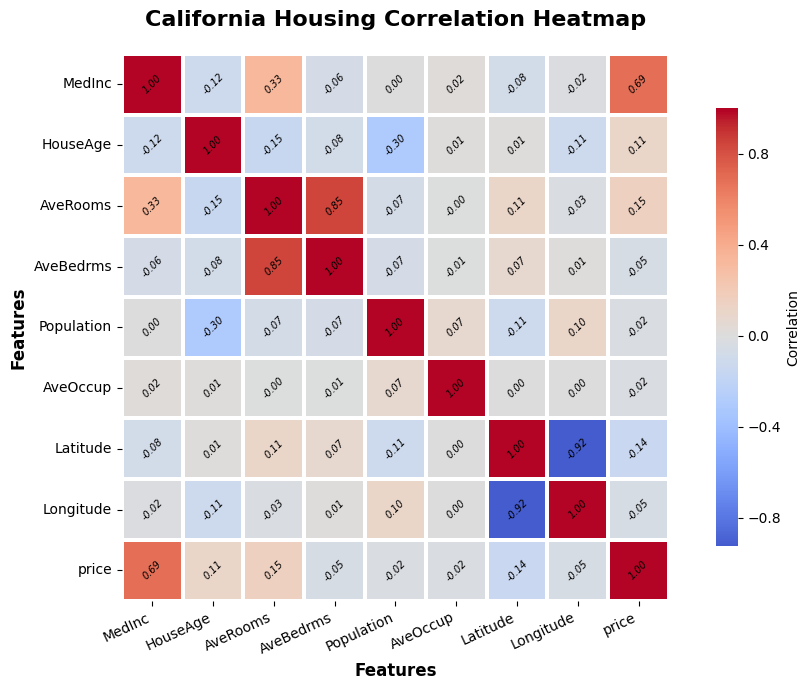

In [76]:
# Lets draw heatmap to vizualize the correlation_data

import  matplotlib.pyplot as plt
import seaborn as sns

# make plotting on big figure (optional)
plt.figure(figsize=(10, 7 )) 

#heatmap
sns.heatmap(
    correlation_data,   # the correlation data
    annot=True,         # show numbers in each square
    fmt='.2f',          # Shows: 0.69, -0.15, etc.
    annot_kws={
        'size': 7,
        'color': 'black',
        'fontweight': 'normal',
        'style': 'italic',
        'rotation': 45
    },                  # Annotation KeyWordS. Lets us customize the annotations 
    cmap='coolwarm',    # red=positive, blue=negative
    cbar=True,          # show colorbar
    center=0,           # set white at 0
    square=True,        # make squares, not rectangles
    linewidths=1.5,     # thin lines between squares
    cbar_kws={
        'shrink': 0.8,
        'label': 'Correlation',
        'orientation': 'vertical',
        'ticks': [-0.8, -0.4, 0, 0.4, 0.8]  # Custom tick marks
    }                   # Color Bar KeyWordS. Lets us customize the color bar
)


# Now some core changes to the graph like title, labels for axes,tick labels
plt.title('California Housing Correlation Heatmap', 
    fontsize=16, 
    fontweight='bold',
    pad=20
)
plt.xlabel('Features', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')

plt.xticks(rotation=25, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

In [85]:
# Lets start the main thing now
# Split data into input and target

X = df.drop(columns='price') # or X = df.drop(['price'], axis=1)
Y = df['price']
print(X)
print(Y)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        -122.23  
1

In [87]:
# Split data into training and test data
# import the lib 
from sklearn.model_selection import train_test_split

# No need to use stratify as the output doesnt have any classes
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

# X_train has 166 inputs ,  Y train has 166 outputs
# X_test has 42 inputs , Y test has 42 outputs
print(X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)

(16512, 8) (4128, 8) (16512,) (4128,)


In [91]:
# Import XGBoost for high-performance gradient boosting regression

from xgboost import XGBRegressor

model = XGBRegressor()

# train the model with training data (X_train) and expected output(Y_train)
model.fit(X_train, Y_train)

#check accuracy
print(model.score(X_train, Y_train))

0.943650140819218


In [96]:
# Now do the same training on test data
model.fit(X_test, Y_test)

#check accuracy
print(model.score(X_test, Y_test))

0.9861852514108522
[2.8527207  1.985583   0.9782482  ... 1.5893257  0.79663825 2.2764437 ]


In [107]:
# Now we can also check 
#  - R-Squared (R²) - "How good is my model?"
#  - Mean Absolute Error (MAE) - "How wrong am I?"

from sklearn.metrics import r2_score, mean_absolute_error

predicted_y_test = model.predict(X_test)
r2 = r2_score(predicted_y_test, Y_test)
mae = mean_absolute_error(predicted_y_test, Y_test)

print(f"R² Score: {r2:.3f}")
print(f"Mean Absolute Error: ${mae:.3f} (in 100k units)")


# Some print statements to show off
print(f"\nIn actual dollars:")
print(f"MAE: ${mae * 100000:,.0f}")
print(f"Average house price: ${Y_test.mean() * 100000:,.0f}")
print(f"R²: {r2:.1%} of variance explained")



R² Score: 0.985
Mean Absolute Error: $0.097 (in 100k units)

In actual dollars:
MAE: $9,749
Average house price: $208,242
R²: 98.5% of variance explained


In [113]:
Y_test.shape

(4128,)

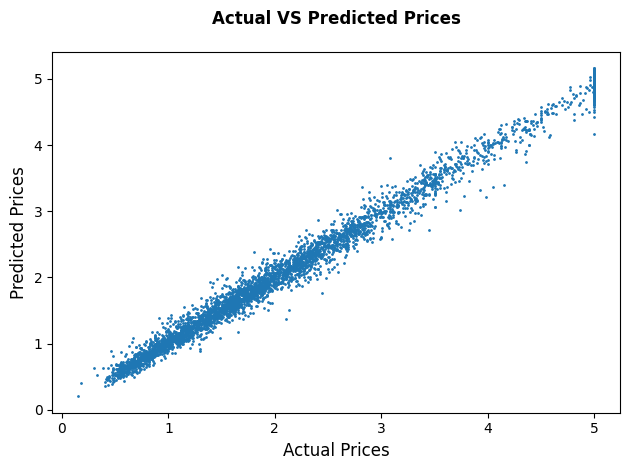

In [126]:
# Wana visualize the actual output vs what the model predicted?
# Ok lets do it
plt.scatter(x=Y_test, y=predicted_y_test, s=1)
plt.title('Actual VS Predicted Prices', 
    fontweight='bold',
    pad=20
)
plt.xlabel('Actual Prices', fontsize=12, fontweight='normal')
plt.ylabel('Predicted Prices', fontsize=12, fontweight='normal')
plt.tight_layout()
plt.show()